# Explore here

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [54]:
data = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=413&path=bank-marketing-campaign-data.csv",sep=";")
pd.set_option('display.max_columns',None)

print(data.info())
print(data.shape)

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [55]:
print(data.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  duration  campaign  pdays  previous     poutcome  \
0   may         mon       261         1    999         0  nonexistent   
1   may         mon       149         1    999         0  nonexistent   
2   may         mon       226         1    999         0  nonexistent   
3   may         mon       151         1    999         0  nonexistent   
4   may         mon       307         1    999         0  nonexistent   

   emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y  
0           1.1          93

In [56]:
#going to convert y to 1 for yes and 0 for no
data['y'] = data['y'].map({"yes": 1, "no":0})

In [57]:
#start data cleaning...check for nulls
print(data.isna().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


<Axes: xlabel='y', ylabel='Count'>

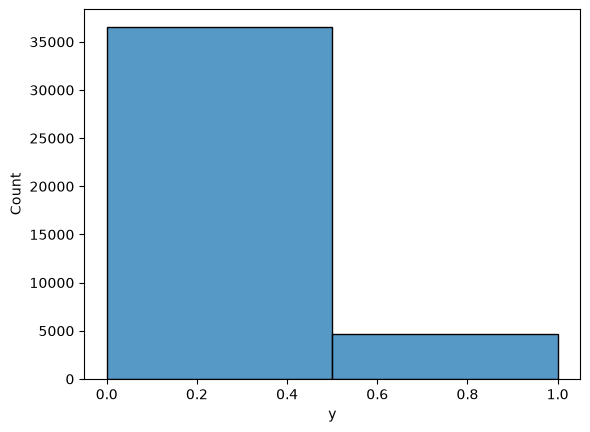

In [58]:
sns.histplot(data=data, x='y',bins=2)
#much more no than yes

In [59]:
#check categorical columns
print(data['job'].value_counts())

print(data.select_dtypes(include="str").nunique())

#can one hot encode without much trouble

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
dtype: int64


In [60]:
print(data.groupby("job")['y'].mean().sort_values(ascending=False))
print("-----")
print(data.groupby("education")['y'].mean().sort_values(ascending=False))

job
student          0.314286
retired          0.252326
unemployed       0.142012
admin.           0.129726
management       0.112175
unknown          0.112121
technician       0.108260
self-employed    0.104856
housemaid        0.100000
entrepreneur     0.085165
services         0.081381
blue-collar      0.068943
Name: y, dtype: float64
-----
education
illiterate             0.222222
unknown                0.145003
university.degree      0.137245
professional.course    0.113485
high.school            0.108355
basic.4y               0.102490
basic.6y               0.082024
basic.9y               0.078246
Name: y, dtype: float64


#definitely can see correlation with both job and education. Very surprising that illiterate and students are both the most likely to make a large deposit

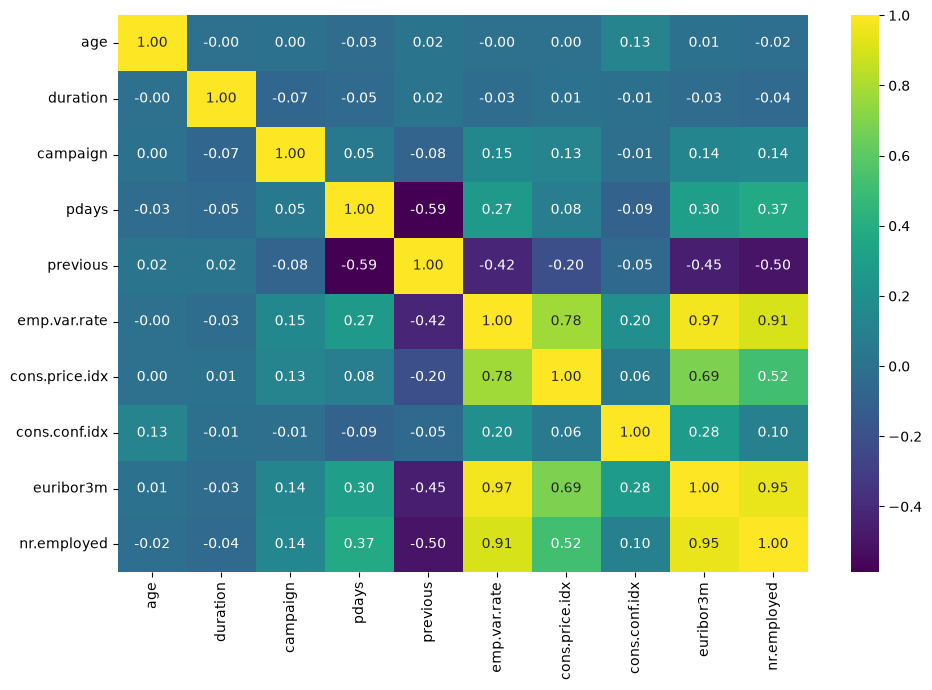

In [61]:
#numerical value correlation heatmap
#correlation matrix
cols_used = ['age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(data[cols_used].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

Highly correlated columns, most noteably euribor3m, nr.employed, and emp.var.rate
Will drop nr.employed and euribor3m

In [62]:
data.drop(columns=['nr.employed','euribor3m'],inplace=True)

In [63]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [64]:
#one hot encoding
categorical_cols = data.select_dtypes(include="str").columns.tolist()
data_transformed = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)

#now split into training and testing
X = data_transformed.drop(columns=['y'])
y = data_transformed['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

#now normalize and one hot encode

numerical_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
numerical_cols = numerical_cols[:-1] #cut off the y column, do not want to normalize
print(numerical_cols)

#normalize
scaler_norm = StandardScaler()
X_train[numerical_cols] = scaler_norm.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler_norm.fit_transform(X_test[numerical_cols])


print(X_train.head())


['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent']
            age  duration  campaign     pdays  previous  emp.var.rate  \
25611  0.863739 -0.120196  0.522981  0.196584 -0.350127     -0.

In [65]:
print(X_train.shape)
print(X_test.shape)

(32950, 51)
(8238, 51)


EDA and data transforming complete! Now to build the logistic regression model

In [66]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [67]:
y_pred = model.predict(X_test)
print(y_pred[:100])

print(accuracy_score(y_test, y_pred))

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
0.9162418062636563


Base accuracy score is 0.916, let's see if we can improve with hyperparameter tuning...

In [68]:
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

#now I see why we need this....
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

grid = GridSearchCV(model, hyperparams, scoring="accuracy",cv = 5)

grid.fit(X_train, y_train)

print(f"Found best hyperparameters: {grid.best_params_}")

Found best hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
model_from_grid = LogisticRegression(penalty="l2",C=0.01, solver="liblinear")
model_from_grid.fit(X_train, y_train)
y_pred_grid = model_from_grid.predict(X_test)

best_grid_acc = accuracy_score(y_test, y_pred_grid)
print(best_grid_acc)

0.915270696771061


In [70]:
#try random search
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

hyperparams_rand = {
    "C": np.logspace(-4,4,20),
    'penalty': ['l1','l2','elasticent', None],
    'solver': ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}
random_search = RandomizedSearchCV(model, hyperparams_rand, n_iter = 100, scoring = "accuracy", cv=5, random_state=42)

random_search.fit(X_train,y_train)
print(f"Found best parameters:{random_search.best_params_}")

Found best parameters:{'solver': 'saga', 'penalty': 'l1', 'C': np.float64(0.03359818286283781)}


In [73]:
model_from_rand = LogisticRegression(penalty="l1", C=np.float64(0.03359818286283781), solver="saga")
model_from_rand.fit(X_train, y_train)
y_pred_rand = model_from_rand.predict(X_test)

best_rand_acc = accuracy_score(y_test, y_pred_rand)
print(best_rand_acc)

0.9145423646516144


Both hyperparameter searches did not yield better results!